<a href="https://colab.research.google.com/github/antonellagambarte/proyecto-final-CEIA/blob/main/PRUEBA_ETAPA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [2]:
ruta_archivo_train = '/content/drive/My Drive/NHANES/dataset_train_imputado.csv'
ruta_archivo_test = '/content/drive/My Drive/NHANES/dataset_test_imputado.csv'


df_train = pd.read_csv(ruta_archivo_train)
df_test = pd.read_csv(ruta_archivo_test)

In [3]:
df_train.head()

,edad,genero,colesterol_total,hdl,ldl,trigliceridos,proteina_c,bmi,fumo_100_cigarrillos,fumador_actual,...,consumo_excesivo_alcohol_ultimo_año_8.0,consumo_excesivo_alcohol_ultimo_año_9.0,consumo_excesivo_alcohol_ultimo_año_10.0,consumo_excesivo_alcohol_ultimo_año_22.0,consumo_excesivo_alcohol_ultimo_año_23.0,consumo_excesivo_alcohol_ultimo_año_99.0,anhedonia_1.0,anhedonia_2.0,anhedonia_3.0,anhedonia_9.0
0,0.027815,1,0.635525,-0.409169,110.804858,1.430187,-0.633385,-0.926269,1,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.598832,1,-0.236009,0.044620,100.609504,-0.035063,-0.681892,-1.527568,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.869431,1,-0.154793,-0.056492,105.080360,-0.040414,-0.646549,-0.547527,1,2.387436,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.084401,1,0.421306,0.838667,118.001130,-0.366252,-0.041933,-0.024172,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.589371,0,0.226934,-0.409169,112.161330,0.702848,0.117120,0.260671,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:
df_test.head()

,edad,genero,colesterol_total,hdl,ldl,trigliceridos,proteina_c,bmi,fumo_100_cigarrillos,fumador_actual,...,consumo_excesivo_alcohol_ultimo_año_8.0,consumo_excesivo_alcohol_ultimo_año_9.0,consumo_excesivo_alcohol_ultimo_año_10.0,consumo_excesivo_alcohol_ultimo_año_22.0,consumo_excesivo_alcohol_ultimo_año_23.0,consumo_excesivo_alcohol_ultimo_año_99.0,anhedonia_1.0,anhedonia_2.0,anhedonia_3.0,anhedonia_9.0
0,0.196138,0,0.770258,-0.658294,150.000000,-0.004461,-0.450077,0.112943,1,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.598832,0,-0.431028,-0.251770,68.593972,1.372133,-1.033075,-1.237209,1,2.387436,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.869431,0,0.658245,-0.251770,135.000000,0.354777,-1.308794,-0.796544,1,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.308353,0,-0.724117,-1.744878,78.000000,1.241630,0.377605,-0.945102,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.084401,1,0.354166,-0.251770,112.198324,0.850878,-0.663495,-0.360865,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 83 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   edad                                      4454 non-null   float64
 1   genero                                    4454 non-null   int64  
 2   colesterol_total                          4454 non-null   float64
 3   hdl                                       4454 non-null   float64
 4   ldl                                       4454 non-null   float64
 5   trigliceridos                             4454 non-null   float64
 6   proteina_c                                4454 non-null   float64
 7   bmi                                       4454 non-null   float64
 8   fumo_100_cigarrillos                      4454 non-null   int64  
 9   fumador_actual                            4454 non-null   float64
 10  act_vigorosa                        

In [6]:
nivel_1_basico = [
    'edad', 'genero', 'fumo_100_cigarrillos', 'actividad_deportiva_moderada_x_semana', 'anhedonia_1.0', 'anhedonia_2.0', 'anhedonia_9.0',
    'anhedonia_3.0', 'consumo_alcohol_ultimo_año_1.0', 'consumo_alcohol_ultimo_año_2.0', 'consumo_alcohol_ultimo_año_3.0',
    'consumo_alcohol_ultimo_año_4.0', 'consumo_alcohol_ultimo_año_5.0', 'consumo_alcohol_ultimo_año_6.0', 'consumo_alcohol_ultimo_año_7.0',
    'consumo_alcohol_ultimo_año_8.0', 'consumo_alcohol_ultimo_año_9.0', 'consumo_alcohol_ultimo_año_10.0', 'consumo_alcohol_ultimo_año_20.0',
    'consumo_alcohol_ultimo_año_99.0',
]

# ETAPA 2
nivel_2_antecedentes = [
     'bmi', 'presion_sistolica_final', 'presion_diastolica_final', 'fam_cardio_2.0','fam_cardio_9.0', 'fam_diabetes_2.0','fam_diabetes_9.0',
     'fam_asma_2.0', 'fam_asma_9.0', 'hipertension_2','hipertension_9', 'diabetes_2.0', 'diabetes_3.0','diabetes_9.0',
     'riñones_debiles_fallando_2.0','riñones_debiles_fallando_9.0'
]



# # # ETAPA 3: Análisis de Laboratorio
# nivel_3_laboratorio = [
#    'colesterol_total', 'hdl', 'trigliceridos', 'proteina_c', 'hemoglobina', 'creatinina', 'acido_urico', 'potasio'
# ]

In [7]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluar_overfitting(
    modelo,
    X_train, y_train,
    X_test, y_test,
    threshold=0.25,
    nombre="Modelo"
):

    # Probabilidades
    prob_train = modelo.predict_proba(X_train)[:, 1]
    prob_test = modelo.predict_proba(X_test)[:, 1]

    # Predicciones binarias
    pred_train = (prob_train >= threshold).astype(int)
    pred_test = (prob_test >= threshold).astype(int)

    # Métricas train
    auc_train = roc_auc_score(y_train, prob_train)
    recall_train = recall_score(y_train, pred_train)
    precision_train = precision_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)

    # Métricas test
    auc_test = roc_auc_score(y_test, prob_test)
    recall_test = recall_score(y_test, pred_test)
    precision_test = precision_score(y_test, pred_test)
    f1_test = f1_score(y_test, pred_test)

    print(f"\n===== {nombre} ====")
    print("---- TRAIN ----")
    print(f"AUC: {auc_train:.4f}")
    print(f"Recall: {recall_train:.4f}")
    print(f"Precision: {precision_train:.4f}")
    print(f"F1: {f1_train:.4f}")

    print("\n---- TEST ----")
    print(f"AUC: {auc_test:.4f}")
    print(f"Recall: {recall_test:.4f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"F1: {f1_test:.4f}")

    auc_gap = auc_train - auc_test
    recall_gap = recall_train - recall_test
    print(f"\n---- GAP (Train-Test) ----")
    print(f"AUC gap: {auc_gap:.4f}")
    print(f"Recall gap: {recall_gap:.4f}")

    # Matriz de confusión para el conjunto de prueba
    cm = confusion_matrix(y_test, pred_test)
    labels = ["Bajo riesgo", "Alto riesgo"]

    # Normalizar la matriz de confusión para mostrar porcentajes
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%", # Formato de porcentaje con 2 decimales
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión Normalizada - {nombre} (TEST)")
    plt.show()

    return {
        "auc_train": auc_train,
        "recall_train": recall_train,
        "precision_train": precision_train,
        "f1_train": f1_train,
        "auc_test": auc_test,
        "recall_test": recall_test,
        "precision_test": precision_test,
        "f1_test": f1_test,
        "auc_gap": auc_gap,
        "recall_gap": recall_gap
    }

In [8]:
# Inicializamos la lista para almacenar los resultados de los modelos
results = []

In [9]:
df_results = pd.DataFrame(results)

In [10]:
df_train_temp = df_train.copy()
df_test_temp = df_test.copy()

In [11]:
TARGET = "alto_riesgo"

X_train = df_train_temp.drop(columns=[TARGET])
y_train = df_train_temp[TARGET]

X_test = df_test_temp.drop(columns=[TARGET])
y_test = df_test_temp[TARGET]

In [12]:
nivel_1_cols = [c for c in nivel_1_basico if c in X_train.columns]
nivel_2_cols = nivel_1_cols + [c for c in nivel_2_antecedentes if c in X_train.columns]
# nivel_3_cols = nivel_2_cols + [c for c in nivel_3_laboratorio if c in X_train.columns]

# Definición de las etapas
etapas = [nivel_2_cols]
nombres_etapas = ["Etapa 1: Básica + Antecedentes"]

In [13]:
X_train_etapa_1 = X_train[etapas[0]]
X_test_etapa_1 = X_test[etapas[0]]

In [14]:
X_train_etapa_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   fumo_100_cigarrillos                   4454 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  4454 non-null   float64
 4   anhedonia_1.0                          4454 non-null   float64
 5   anhedonia_2.0                          4454 non-null   float64
 6   anhedonia_9.0                          4454 non-null   float64
 7   anhedonia_3.0                          4454 non-null   float64
 8   consumo_alcohol_ultimo_año_1.0         4454 non-null   float64
 9   consumo_alcohol_ultimo_año_2.0         4454 non-null   float64
 10  consumo_alcohol_ultimo_año_3.0         4454 non-null   float64
 11  cons

In [15]:
X_test_etapa_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   1114 non-null   float64
 1   genero                                 1114 non-null   int64  
 2   fumo_100_cigarrillos                   1114 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  1114 non-null   float64
 4   anhedonia_1.0                          1114 non-null   float64
 5   anhedonia_2.0                          1114 non-null   float64
 6   anhedonia_9.0                          1114 non-null   float64
 7   anhedonia_3.0                          1114 non-null   float64
 8   consumo_alcohol_ultimo_año_1.0         1114 non-null   float64
 9   consumo_alcohol_ultimo_año_2.0         1114 non-null   float64
 10  consumo_alcohol_ultimo_año_3.0         1114 non-null   float64
 11  cons

ramdom forrest


===== Random Forest (Class Weight Balanced) ====
---- TRAIN ----
AUC: 0.8832
Recall: 0.9458
Precision: 0.2544
F1: 0.4009

---- TEST ----
AUC: 0.8430
Recall: 0.9058
Precision: 0.2465
F1: 0.3876

---- GAP (Train-Test) ----
AUC gap: 0.0402
Recall gap: 0.0400


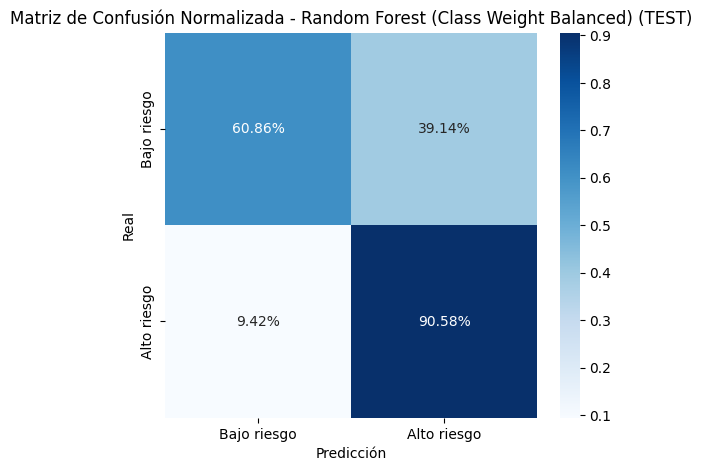

In [16]:
# Modelo Random Forest con class_weight='balanced'
modelo_rf_balanced_weight = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

modelo_rf_balanced_weight.fit(X_train_etapa_1, y_train)

rf_balanced_weight_metrics = evaluar_overfitting(
    modelo_rf_balanced_weight,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest (Class Weight Balanced)"
)

results.append({"Modelo": "Random Forest (Class Weight Balanced)", **rf_balanced_weight_metrics})

Antes SMOTE:
alto_riesgo
0    3901
1     553
Name: count, dtype: int64

Después SMOTE:
alto_riesgo
0    3901
1    3120
Name: count, dtype: int64

===== Random Forest + SMOTE ====
---- TRAIN ----
AUC: 0.9309
Recall: 0.9288
Precision: 0.7463
F1: 0.8276

---- TEST ----
AUC: 0.8408
Recall: 0.7971
Precision: 0.3073
F1: 0.4435

---- GAP (Train-Test) ----
AUC gap: 0.0901
Recall gap: 0.1317


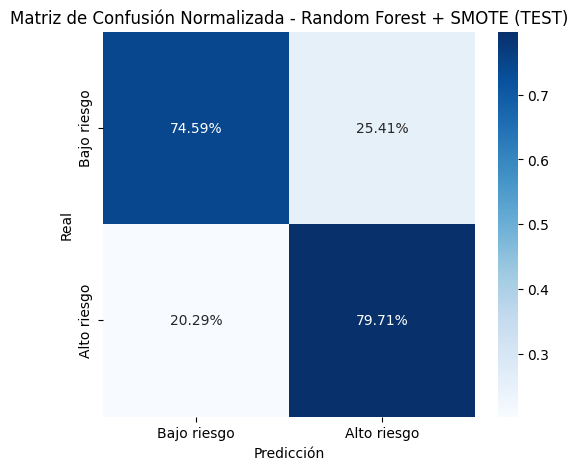

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(
    sampling_strategy=0.8,
    random_state=42,
    k_neighbors=5
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_etapa_1, y_train)

print("Antes SMOTE:")
print(y_train.value_counts())

print("\nDespués SMOTE:")
print(y_train_sm.value_counts())


# Modelo
modelo_smote = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

modelo_smote.fit(X_train_sm, y_train_sm)

rf_smote_metrics = evaluar_overfitting(
    modelo_smote,
    X_train_sm, y_train_sm,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest + SMOTE"
)

results.append({"Modelo": "Random Forest + SMOTE", **rf_smote_metrics})

In [18]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train_etapa_1, y_train)

print("Antes Undersampling:")
print(y_train.value_counts())

print("\nDespués Undersampling:")
print(y_train_under.value_counts())

Antes Undersampling:
alto_riesgo
0    3901
1     553
Name: count, dtype: int64

Después Undersampling:
alto_riesgo
0    691
1    553
Name: count, dtype: int64



===== Random Forest (Undersampling) ====
---- TRAIN ----
AUC: 0.9007
Recall: 0.9259
Precision: 0.6910
F1: 0.7913

---- TEST ----
AUC: 0.8420
Recall: 0.8768
Precision: 0.2602
F1: 0.4013

---- GAP (Train-Test) ----
AUC gap: 0.0588
Recall gap: 0.0490


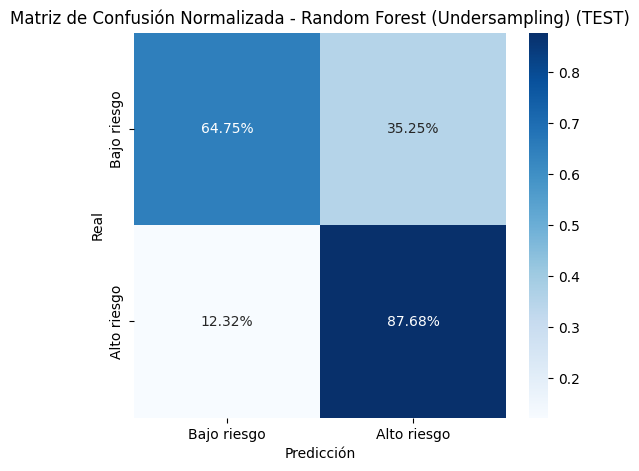

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest con Undersampling
modelo_rf_under = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

modelo_rf_under.fit(X_train_under, y_train_under)

rf_under_metrics = evaluar_overfitting(
    modelo_rf_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest (Undersampling)"
)

results.append({"Modelo": "Random Forest (Undersampling)", **rf_under_metrics})

xboost


===== XGBoost - balanceo propio ====
---- TRAIN ----
AUC: 0.8723
Recall: 0.9150
Precision: 0.2642
F1: 0.4100

---- TEST ----
AUC: 0.8449
Recall: 0.8913
Precision: 0.2623
F1: 0.4053

---- GAP (Train-Test) ----
AUC gap: 0.0275
Recall gap: 0.0237


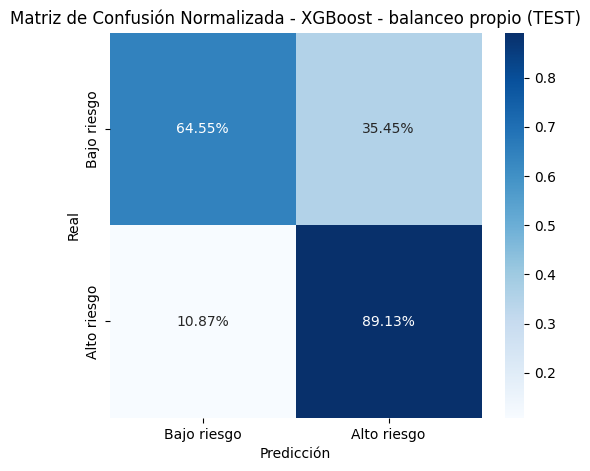

In [20]:
from xgboost import XGBClassifier

# ratio clases para penalización
ratio = (y_train == 0).sum() / (y_train == 1).sum() #9.55

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=ratio,
    eval_metric="aucpr",
    random_state=42
)

modelo_xgb.fit(X_train_etapa_1, y_train)

xgb_metrics = evaluar_overfitting(
    modelo_xgb,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="XGBoost - balanceo propio"
)

results.append({"Modelo": "XGBoost - balanceo propio", **xgb_metrics})


===== XGBoost - SMOTE ====
---- TRAIN ----
AUC: 0.9343
Recall: 0.9167
Precision: 0.7574
F1: 0.8295

---- TEST ----
AUC: 0.8368
Recall: 0.7899
Precision: 0.3196
F1: 0.4551

---- GAP (Train-Test) ----
AUC gap: 0.0975
Recall gap: 0.1268


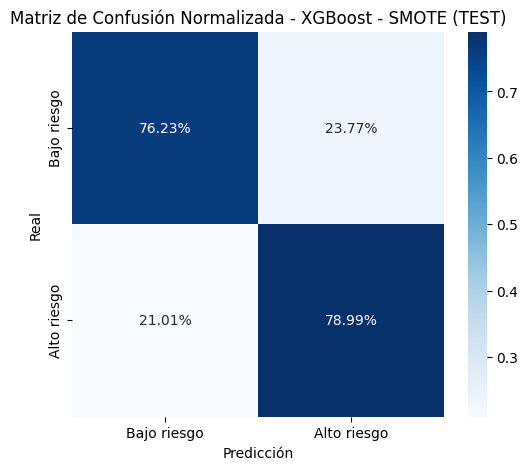

In [21]:
from xgboost import XGBClassifier

# ratio clases para penalización
ratio = (y_train == 0).sum() / (y_train == 1).sum() #9.55

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=1,
    eval_metric="aucpr",
    random_state=42
)

modelo_xgb.fit(X_train_sm, y_train_sm)

xgb_metrics = evaluar_overfitting(
    modelo_xgb,
    X_train_sm, y_train_sm,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="XGBoost - SMOTE"
)

results.append({"Modelo": "XGBoost - SMOTE", **xgb_metrics})


===== XGBoost - undersampling ====
---- TRAIN ----
AUC: 0.8832
Recall: 0.8770
Precision: 0.7049
F1: 0.7816

---- TEST ----
AUC: 0.8422
Recall: 0.8261
Precision: 0.2836
F1: 0.4222

---- GAP (Train-Test) ----
AUC gap: 0.0410
Recall gap: 0.0509


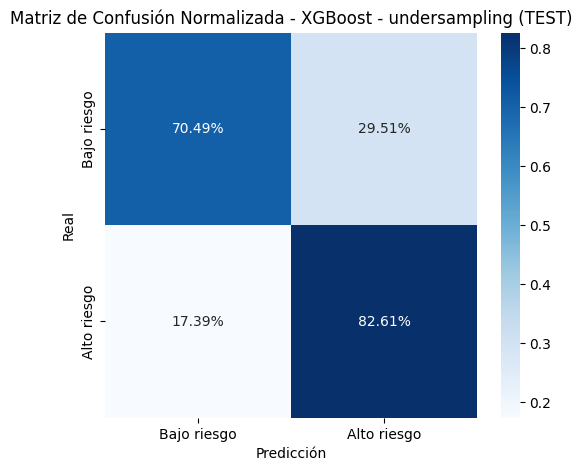

In [22]:
from xgboost import XGBClassifier

# ratio clases para penalización
ratio = (y_train == 0).sum() / (y_train == 1).sum() #9.55

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=1,
    eval_metric="aucpr",
    random_state=42
)

modelo_xgb.fit(X_train_under, y_train_under)

xgb_metrics = evaluar_overfitting(
    modelo_xgb,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="XGBoost - undersampling"
)

results.append({"Modelo": "XGBoost - undersampling", **xgb_metrics})

balanced ramdom forest


===== Balanced RF (Class Weight Balanced) ====
---- TRAIN ----
AUC: 0.9983
Recall: 1.0000
Precision: 0.3856
F1: 0.5566

---- TEST ----
AUC: 0.8400
Recall: 0.7899
Precision: 0.2946
F1: 0.4291

---- GAP (Train-Test) ----
AUC gap: 0.1583
Recall gap: 0.2101


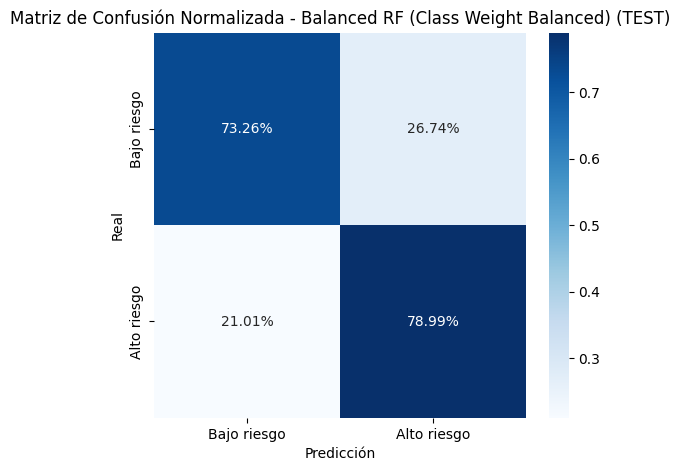

In [23]:
from imblearn.ensemble import BalancedRandomForestClassifier

modelo_brf = BalancedRandomForestClassifier(
    n_estimators=400,
    random_state=42
)

modelo_brf.fit(X_train_etapa_1, y_train)

brf_metrics = evaluar_overfitting(
    modelo_brf,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Balanced RF (Class Weight Balanced)"
)

results.append({"Modelo": "Balanced Random Forest (Class Weight Balanced)", **brf_metrics})

logistic regression


===== Logistic Regression (Class Weight Balanced) ====
---- TRAIN ----
AUC: 0.8673
Recall: 0.8734
Precision: 0.2831
F1: 0.4276

---- TEST ----
AUC: 0.8427
Recall: 0.8333
Precision: 0.2778
F1: 0.4167

---- GAP (Train-Test) ----
AUC gap: 0.0246
Recall gap: 0.0401


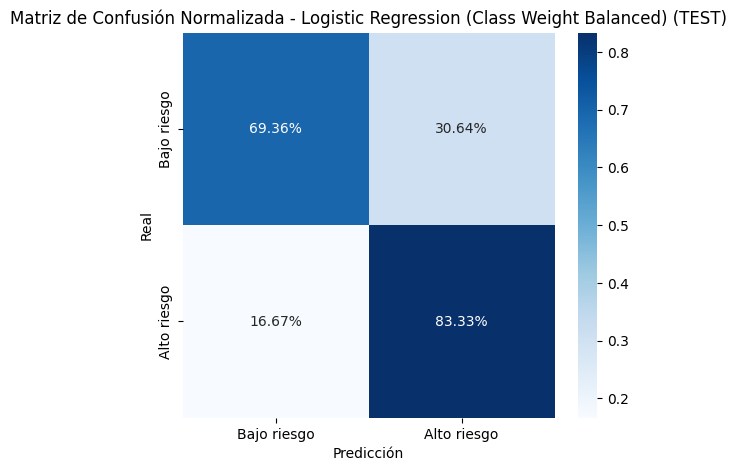

In [24]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

modelo_lr.fit(X_train_etapa_1, y_train)

lr_metrics = evaluar_overfitting(
    modelo_lr,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Logistic Regression (Class Weight Balanced)"
)

results.append({"Modelo": "Logistic Regression", **lr_metrics})


===== Logistic Regression + SMOTE ====
---- TRAIN ----
AUC: 0.8803
Recall: 0.8596
Precision: 0.7268
F1: 0.7877

---- TEST ----
AUC: 0.8355
Recall: 0.8116
Precision: 0.3102
F1: 0.4489

---- GAP (Train-Test) ----
AUC gap: 0.0449
Recall gap: 0.0480


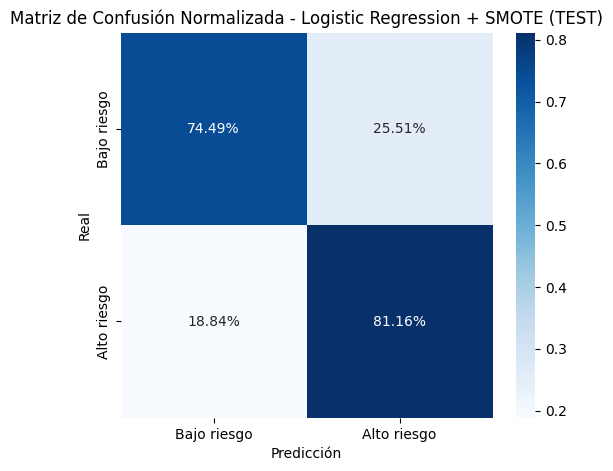

In [25]:
from sklearn.linear_model import LogisticRegression

modelo_lr_smote = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo_lr_smote.fit(X_train_sm, y_train_sm)

lr_smote_metrics = evaluar_overfitting(
    modelo_lr_smote,
    X_train_sm, y_train_sm,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Logistic Regression + SMOTE"
)

results.append({"Modelo": "Logistic Regression + SMOTE", **lr_smote_metrics})


===== Logistic Regression + Undersampling ====
---- TRAIN ----
AUC: 0.8750
Recall: 0.8535
Precision: 0.7217
F1: 0.7821

---- TEST ----
AUC: 0.8389
Recall: 0.7899
Precision: 0.2946
F1: 0.4291

---- GAP (Train-Test) ----
AUC gap: 0.0361
Recall gap: 0.0637


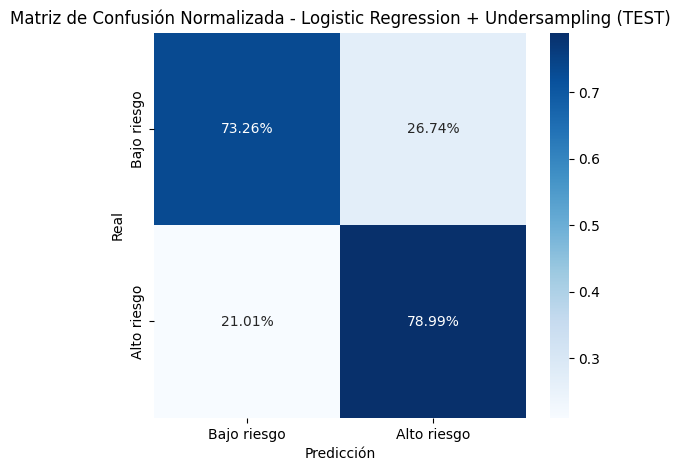

In [26]:
from sklearn.linear_model import LogisticRegression

modelo_lr_under = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo_lr_under.fit(X_train_under, y_train_under)

lr_under_metrics = evaluar_overfitting(
    modelo_lr_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Logistic Regression + Undersampling"
)

results.append({"Modelo": "Logistic Regression + Undersampling", **lr_under_metrics})

decision tree


===== Decision Tree (Class Weight Balanced) ====
---- TRAIN ----
AUC: 0.8608
Recall: 0.9042
Precision: 0.2710
F1: 0.4170

---- TEST ----
AUC: 0.7974
Recall: 0.8478
Precision: 0.2612
F1: 0.3993

---- GAP (Train-Test) ----
AUC gap: 0.0634
Recall gap: 0.0563


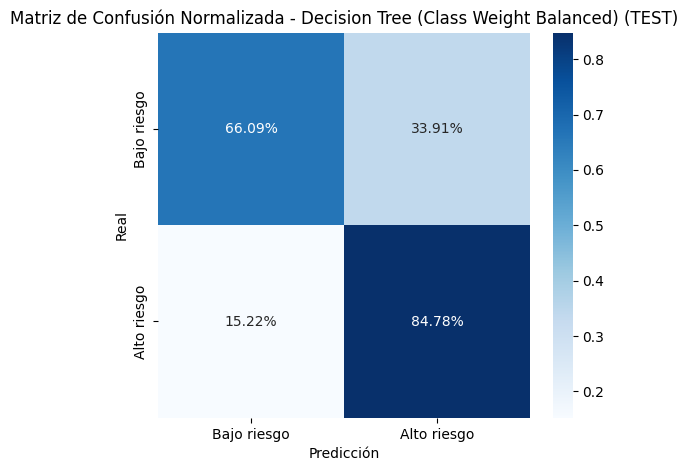

In [27]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

modelo_dt.fit(X_train_etapa_1, y_train)

dt_metrics = evaluar_overfitting(
    modelo_dt,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Decision Tree (Class Weight Balanced)"
)

results.append({"Modelo": "Decision Tree Classifier", **dt_metrics})


===== Decision Tree + SMOTE ====
---- TRAIN ----
AUC: 0.9074
Recall: 0.8526
Precision: 0.7919
F1: 0.8211

---- TEST ----
AUC: 0.7885
Recall: 0.5145
Precision: 0.2806
F1: 0.3632

---- GAP (Train-Test) ----
AUC gap: 0.1189
Recall gap: 0.3381


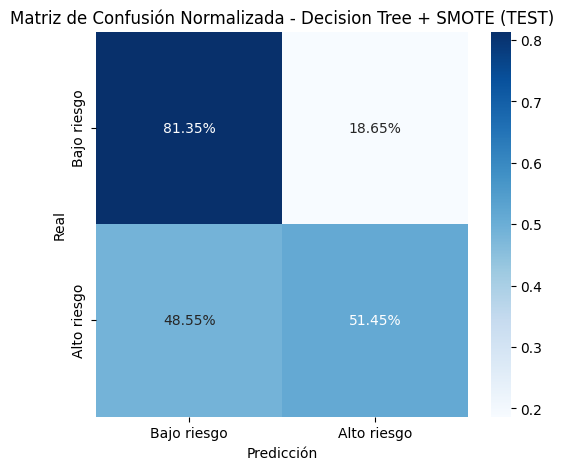

In [28]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt_smote = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_dt_smote.fit(X_train_sm, y_train_sm)

dt_smote_metrics = evaluar_overfitting(
    modelo_dt_smote,
    X_train_sm, y_train_sm,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Decision Tree + SMOTE"
)

results.append({"Modelo": "Decision Tree + SMOTE", **dt_smote_metrics})


===== Decision Tree + Undersampling ====
---- TRAIN ----
AUC: 0.8754
Recall: 0.8427
Precision: 0.7385
F1: 0.7872

---- TEST ----
AUC: 0.7843
Recall: 0.7029
Precision: 0.2764
F1: 0.3967

---- GAP (Train-Test) ----
AUC gap: 0.0911
Recall gap: 0.1398


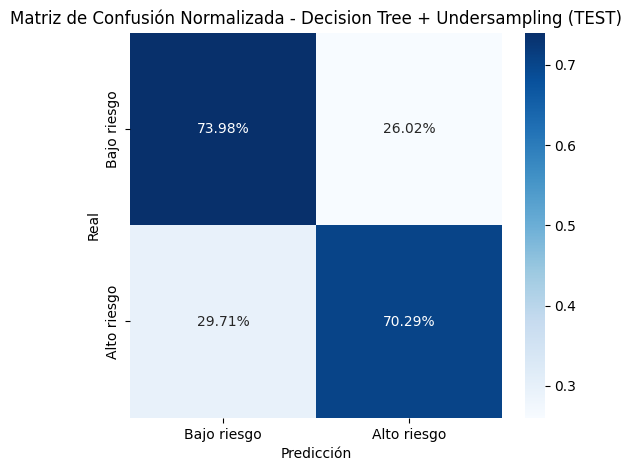

In [29]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt_under = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_dt_under.fit(X_train_under, y_train_under)

dt_under_metrics = evaluar_overfitting(
    modelo_dt_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Decision Tree + Undersampling"
)

results.append({"Modelo": "Decision Tree + Undersampling", **dt_under_metrics})

SVM


===== SVM Linear Kernel (Class Weight Balanced) ====
---- TRAIN ----
AUC: 0.8659
Recall: 0.2785
Precision: 0.5016
F1: 0.3581

---- TEST ----
AUC: 0.8399
Recall: 0.2609
Precision: 0.4737
F1: 0.3364

---- GAP (Train-Test) ----
AUC gap: 0.0261
Recall gap: 0.0176


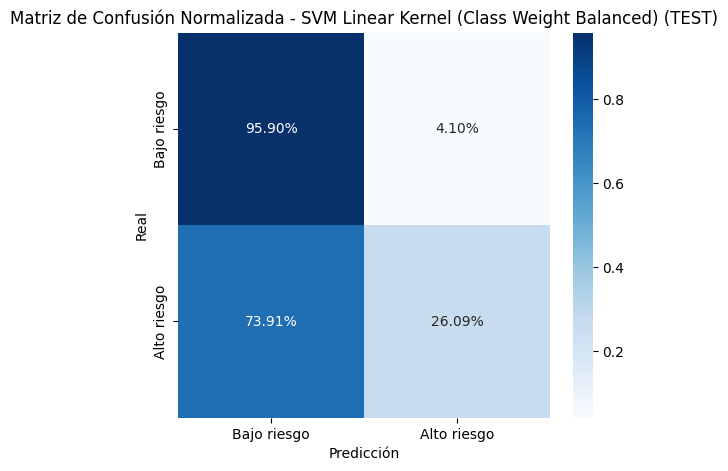

In [30]:
from sklearn.svm import SVC

modelo_svm = SVC(
    kernel='linear',
    probability=True,
    random_state=42,
    class_weight='balanced'
)

modelo_svm.fit(X_train_etapa_1, y_train)

svm_metrics = evaluar_overfitting(
    modelo_svm,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="SVM Linear Kernel (Class Weight Balanced)"
)

results.append({"Modelo": "SVM Linear Kernel", **svm_metrics})


===== SVM Linear Kernel + SMOTE ====
---- TRAIN ----
AUC: 0.8804
Recall: 0.8590
Precision: 0.7298
F1: 0.7892

---- TEST ----
AUC: 0.8341
Recall: 0.7754
Precision: 0.3066
F1: 0.4394

---- GAP (Train-Test) ----
AUC gap: 0.0463
Recall gap: 0.0836


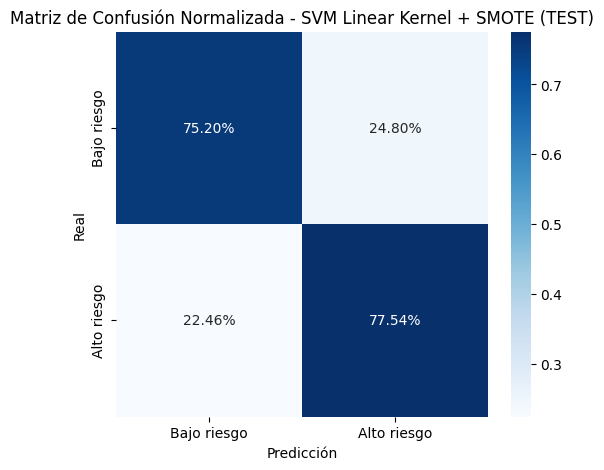

In [31]:
from sklearn.svm import SVC

modelo_svm_smote = SVC(
    kernel='linear',
    probability=True,
    random_state=42,
)

modelo_svm_smote.fit(X_train_sm, y_train_sm)

svm_smote_metrics = evaluar_overfitting(
    modelo_svm_smote,
    X_train_sm, y_train_sm,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="SVM Linear Kernel + SMOTE"
)

results.append({"Modelo": "SVM Linear Kernel + SMOTE", **svm_smote_metrics})


===== SVM Linear Kernel + Undersampling ====
---- TRAIN ----
AUC: 0.8745
Recall: 0.8553
Precision: 0.7210
F1: 0.7825

---- TEST ----
AUC: 0.8325
Recall: 0.7826
Precision: 0.2903
F1: 0.4235

---- GAP (Train-Test) ----
AUC gap: 0.0420
Recall gap: 0.0727


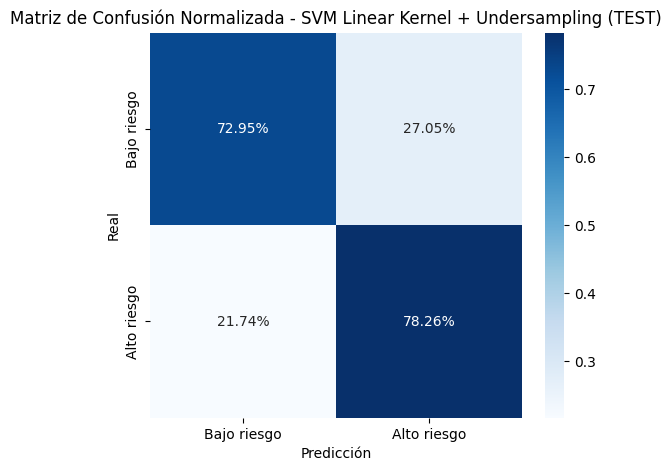

In [32]:
from sklearn.svm import SVC

modelo_svm_under = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

modelo_svm_under.fit(X_train_under, y_train_under)

svm_under_metrics = evaluar_overfitting(
    modelo_svm_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="SVM Linear Kernel + Undersampling"
)

results.append({"Modelo": "SVM Linear Kernel + Undersampling", **svm_under_metrics})

catboost

In [33]:
!pip install catboost


===== Catboost - balanceo propio ====
---- TRAIN ----
AUC: 0.9207
Recall: 0.9403
Precision: 0.3163
F1: 0.4734

---- TEST ----
AUC: 0.8448
Recall: 0.8261
Precision: 0.2879
F1: 0.4270

---- GAP (Train-Test) ----
AUC gap: 0.0759
Recall gap: 0.1142


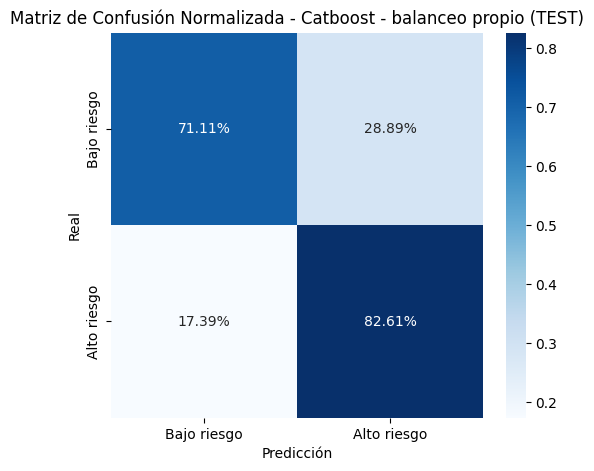

In [34]:
from catboost import CatBoostClassifier
import pandas as pd
import matplotlib.pyplot as plt

# modelo_etapa_cat = CatBoostClassifier(
#       iterations=500,
#       depth=4,
#       learning_rate=0.05,
#       min_data_in_leaf=10,
#       l2_leaf_reg=5,
#       subsample=0.8,
#       colsample_bylevel=0.8,
#       auto_class_weights='Balanced',
#       cat_features=[],
#       verbose=0,
#       random_state=42
#     )

modelo_etapa_cat = CatBoostClassifier(
      iterations=1000,
      learning_rate=0.02,
      depth=4,
      l2_leaf_reg=15,
      min_data_in_leaf=25,
      subsample=0.8,
      colsample_bylevel=0.8,
      scale_pos_weight=(sum(y_train==0)/sum(y_train==1)),
      random_state=42,
      verbose=0
    )

# Entrenar modelo
modelo_etapa_cat.fit(X_train_etapa_1, y_train)


metricas_cat_etapa = evaluar_overfitting(
        modelo_etapa_cat,
        X_train_etapa_1, y_train,
        X_test_etapa_1, y_test,
        threshold=0.4,
        nombre="Catboost - balanceo propio"
    )
results.append({"Modelo": "SVM Linear Kernel + Undersampling", **svm_under_metrics})
    # Guardar métricas
results.append({"Modelo": "Catboost - balanceo propio", **metricas_cat_etapa})

----------------------------------------------------------------

In [35]:
import pandas as pd

df_results = pd.DataFrame(results)

print("pruebas con balanceo:")
df_results

pruebas con balanceo:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest (Class Weight Balanced),0.883229,0.945750,0.254377,0.400920,0.843008,0.905797,0.246548,0.387597,0.040221,0.039953
1,Random Forest + SMOTE,0.930885,0.928846,0.746330,0.827645,0.840758,0.797101,0.307263,0.443548,0.090127,0.131745
2,Random Forest (Undersampling),0.900736,0.925859,0.690958,0.791345,0.841953,0.876812,0.260215,0.401327,0.058783,0.049047
3,XGBoost - balanceo propio,0.872328,0.915009,0.264230,0.410049,0.844871,0.891304,0.262260,0.405272,0.027457,0.023705
4,XGBoost - SMOTE,0.934344,0.916667,0.757415,0.829466,0.836801,0.789855,0.319648,0.455115,0.097544,0.126812
5,XGBoost - undersampling,0.883227,0.877034,0.704942,0.781628,0.842191,0.826087,0.283582,0.422222,0.041037,0.050947
6,Balanced Random Forest (Class Weight Balanced),0.998271,1.000000,0.385635,0.556618,0.839993,0.789855,0.294595,0.429134,0.158278,0.210145
7,Logistic Regression,0.867295,0.873418,0.283118,0.427623,0.842718,0.833333,0.277778,0.416667,0.024577,0.040084
8,Logistic Regression + SMOTE,0.880337,0.859615,0.726829,0.787665,0.835486,0.811594,0.310249,0.448898,0.044851,0.048021
9,Logistic Regression + Undersampling,0.874983,0.853526,0.721713,0.782104,0.838865,0.789855,0.294595,0.429134,0.036118,0.063671


Mejores: 0 - Random Forest (Class Weight Balanced), 3 - XGBoost - balanceo propio, 2 - Random Forest (Undersampling)